In [6]:
import tensorflow as tf
import numpy as np

In [7]:
model = tf.keras.models.load_model(
    "../models/unet_bce_dice_best.keras",
    compile=False
)

In [9]:
def load_images_masks(image_path, mask_path):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.convert_image_dtype(mask, tf.float32)

    return image, mask

In [10]:
from pathlib import Path

datasetPath = Path("../dataset/data_wound_seg_256")

test_images_path = sorted(
    (datasetPath / "test_images").glob("*.png")
)

test_masks_path = sorted(
    (datasetPath / "test_masks").glob("*.png")
)

test_images_path = [str(p) for p in test_images_path]
test_masks_path = [str(p) for p in test_masks_path]

In [11]:
BATCH_SIZE = 2

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_images_path, test_masks_path)
)

test_dataset = test_dataset.map(
    load_images_masks
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [12]:
for images, masks in test_dataset.take(1):
    print("Images:", images.shape)
    print("Masks:", masks.shape)

Images: (2, 256, 256, 3)
Masks: (2, 256, 256, 1)


In [13]:
dice_scores = []
iou_scores = []

for images, masks in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    for i in range(images.shape[0]):

        gt = masks[i].numpy().squeeze() > 0.5
        pred = predictions[i].squeeze() > 0.5

        intersection = np.logical_and(gt, pred).sum()
        union = np.logical_or(gt, pred).sum()

        dice = (2 * intersection) / (
            gt.sum() + pred.sum() + 1e-7
        )

        iou = intersection / (
            union + 1e-7
        )

        dice_scores.append(dice)
        iou_scores.append(iou)

print("Test images:", len(dice_scores))
print("Mean Dice:", np.mean(dice_scores))
print("Mean IoU:", np.mean(iou_scores))

2026-08-18 22:23:25.818973: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


Test images: 552
Mean Dice: 0.7632949826687083
Mean IoU: 0.6737591616345613


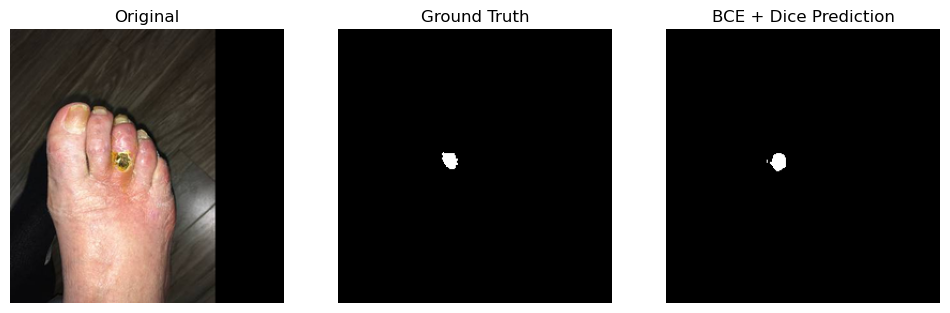

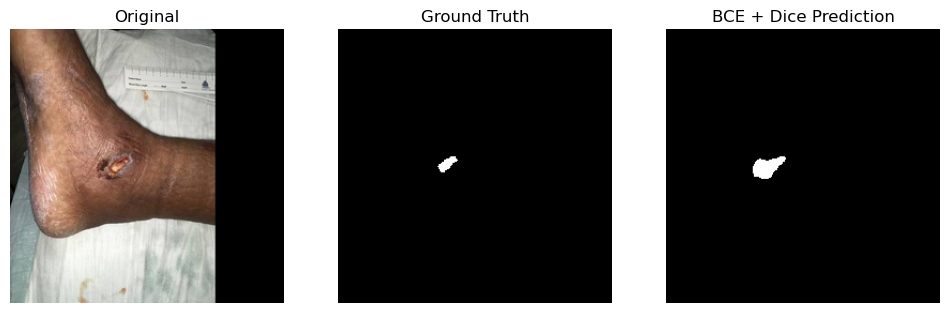

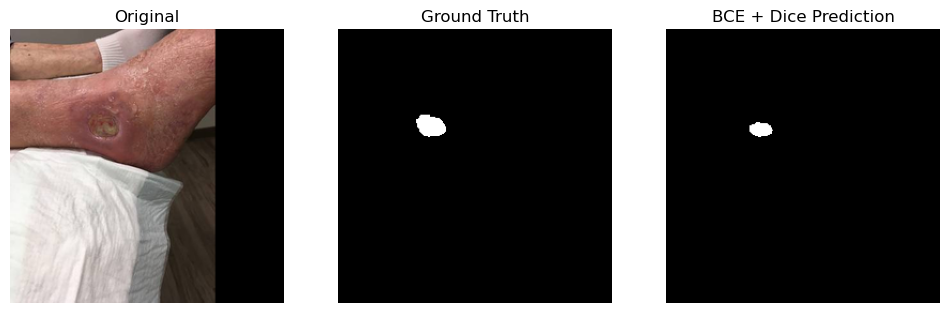

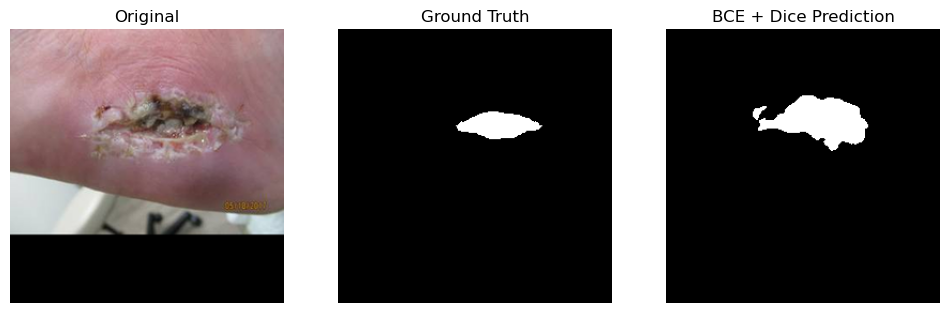

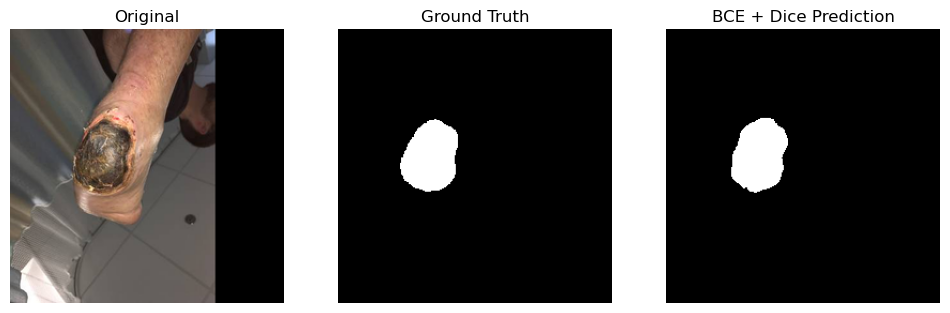

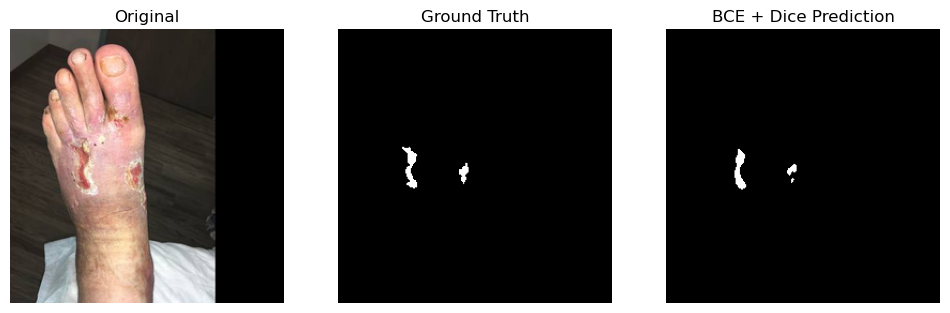

In [14]:
import matplotlib.pyplot as plt

for images, masks in test_dataset.take(3):

    predictions = model.predict(
        images,
        verbose=0
    )

    for i in range(images.shape[0]):

        plt.figure(figsize=(12, 4))

        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(images[i])
        plt.title("Original")
        plt.axis("off")

        # Ground truth
        plt.subplot(1, 3, 2)
        plt.imshow(
            masks[i].numpy().squeeze(),
            cmap="gray"
        )
        plt.title("Ground Truth")
        plt.axis("off")

        # Prediction
        plt.subplot(1, 3, 3)
        plt.imshow(
            predictions[i].squeeze() > 0.5,
            cmap="gray"
        )
        plt.title("BCE + Dice Prediction")
        plt.axis("off")

        plt.show()